# 02: Spatial patterns and models

Notebook 01 showed that rates climb with remoteness and disadvantage. Here I want to answer the actual
question: **which areas have more preventable admissions than their social, demographic and access profile
predicts?** To get there I need three things:

1. a check of how clustered the rates are on the map, because that decides how I have to test the models;
2. a set of models, from "just guess the national average" up to gradient-boosted trees, tested in a way that
   doesn't let neighbouring areas give away the answer;
3. a map of what the best model *can't* explain.

All the work happens in `uv run dap health train` (code in `src/dap/health/`). It writes
`reports/results.json` and the figures, and this notebook runs it and then reads its outputs.
Run `dap health fetch` and `dap health build` first if you haven't.

In [1]:
import pandas as pd
from IPython.display import Image, display

from dap.common import paths
from dap.health.models import MODELS
from dap.health.train import train

pd.set_option("display.precision", 3)
FIGURES = paths.reports_dir() / "figures"

out = train()  # about 40 seconds: every model, both CV schemes, 5 repeats each
r = out["stats"]
t = r["target"]
print(f"{t['areas']} SA3s in {t['sa4_groups']} SA4s, {t['features']} Tier A features")


def show(name):
    display(Image(filename=FIGURES / name, width=760))

327 SA3s in 88 SA4s, 42 Tier A features


## How clustered are the rates?

Global Moran's I measures how alike neighbouring areas are. It's roughly a correlation between each area's
(log) rate and the average of its neighbours: 0 means no pattern, and 1 means neighbours are identical. I used
Queen contiguity (areas that share a border or a corner are neighbours), built only on the 327 areas that have
a rate, so the suppressed areas don't leave hidden holes.

In [2]:
a = r["spatial_autocorrelation"]
print("Weights:", a["weights"])
m = a["moran_log_pph"]
print(f"Moran's I of log rate: {m['I']:.2f} (permutation p = {m['p_sim']})")
pd.Series(a["lisa_clusters"], name="SA3s")

Weights: {'areas': 327, 'mean_neighbours': 4.758, 'islands': 0, 'components': 2}
Moran's I of log rate: 0.71 (permutation p = 0.001)


High-high           51
Low-high             2
Low-low             52
High-low             2
Not significant    220
Name: SA3s, dtype: int64

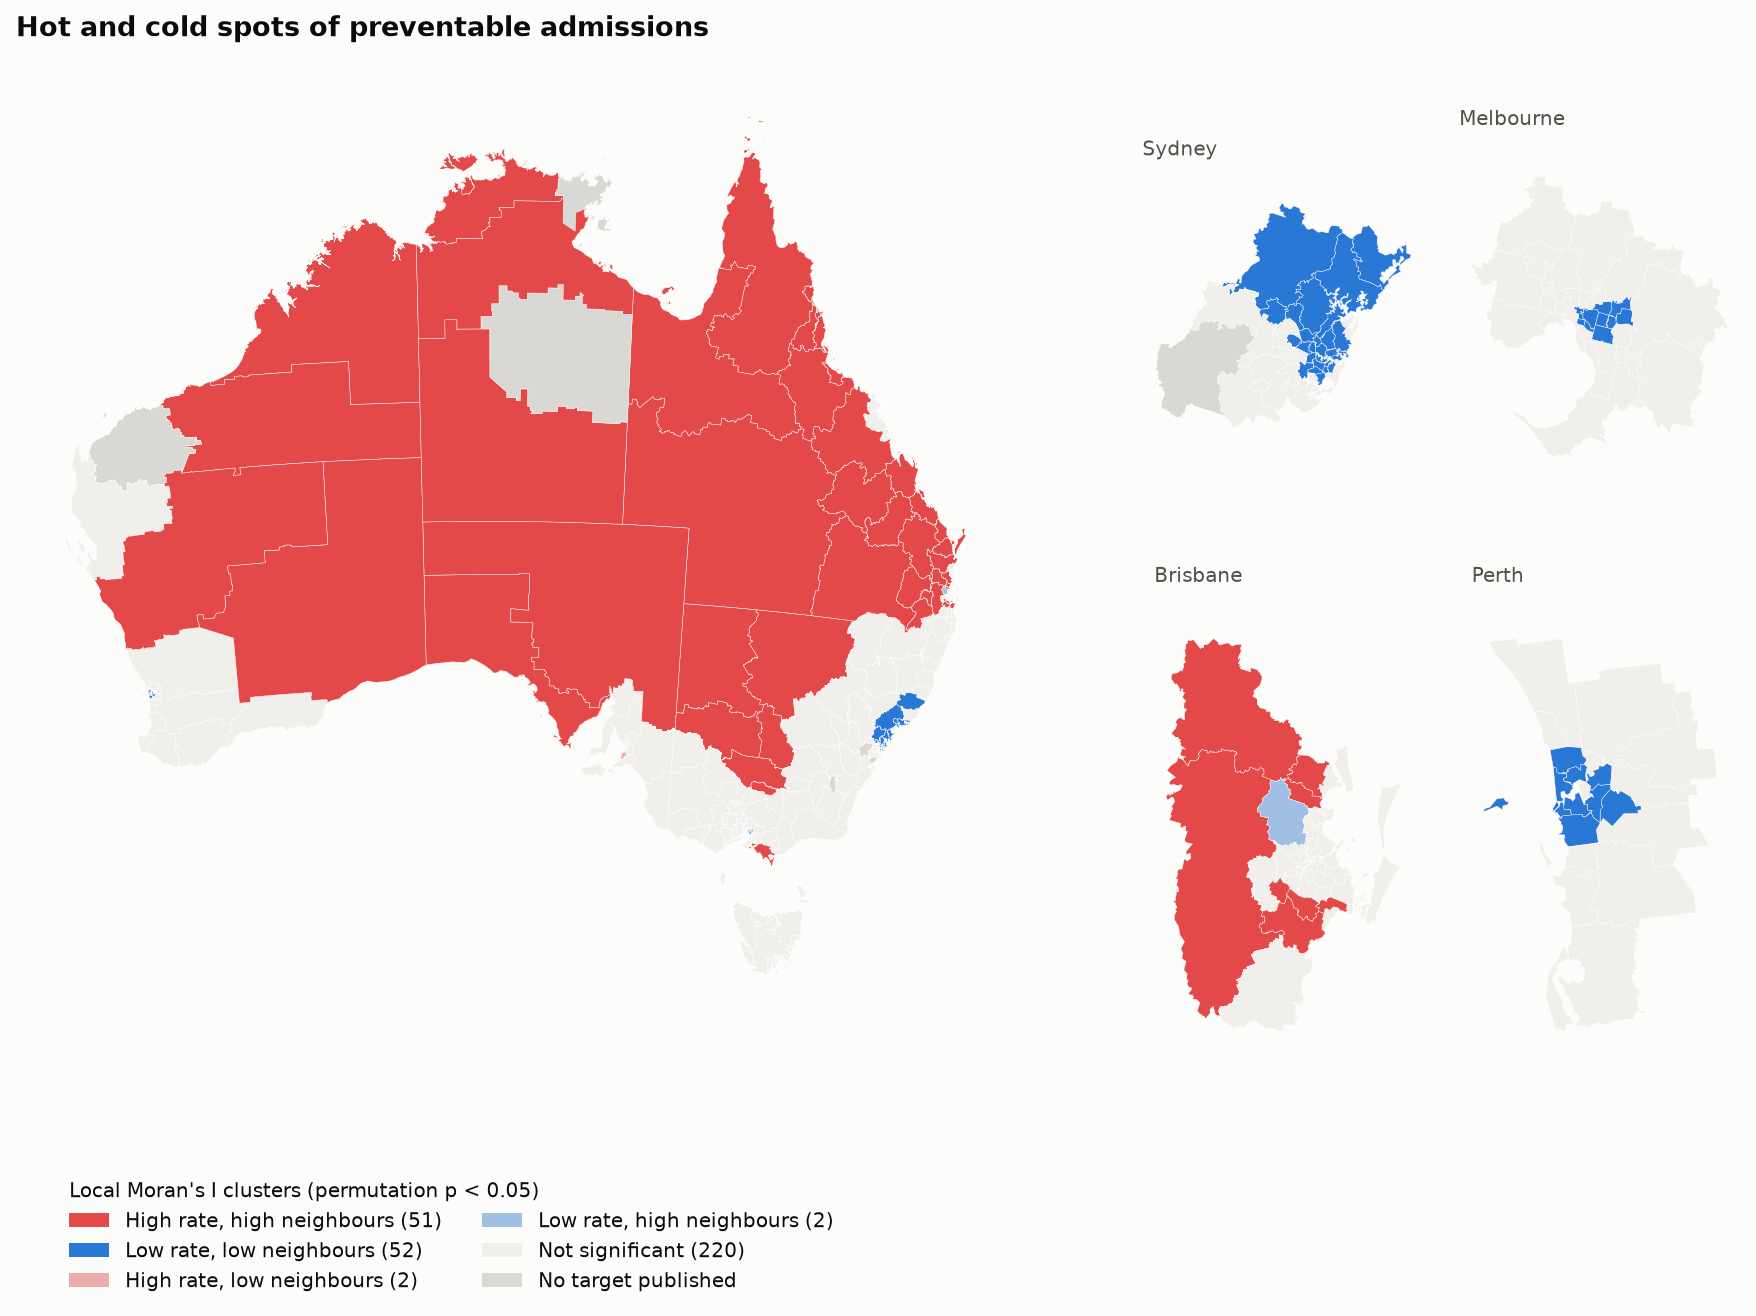

In [3]:
show("02_lisa_map.png")

That's a strong pattern. A Moran's I around 0.7 means an area's rate is very predictable from its neighbours'
rates. The two "components" are mainland Australia and Tasmania, which don't share a border with anything.

The local version (LISA) splits this into hot and cold spots. The hot spots cover almost all of the remote north
and west, plus a band through inland Queensland. The cold spots are in the big cities: most of Sydney, inner
Melbourne and Perth's inner suburbs. The p-values aren't adjusted for testing 327 areas at once, so I'm treating
these as "where to look", not as proof.

This matters for testing. If I split areas into training and test sets at random, most test areas will have a
neighbour in the training set, and a flexible model can partly "recognise" the neighbourhood instead of learning
anything general.

## Models, and two ways to test them

Every model predicts the log of the rate (the rate is skewed, see notebook 01), and every error is measured on
the original scale, weighted by population, so a big city SA3 counts for more than a tiny remote one. The five
models, from simplest to most complex:

| Model | What it does |
|---|---|
| National mean | Predicts the same rate everywhere. Anything useful has to beat this. |
| Remoteness x state means | The average rate for areas in the same state with the same main remoteness class (from ABS population shares). |
| Ridge regression | A linear model on all 42 features, with missing values filled and features scaled inside each training fold. |
| Spatial lag | A linear model where an area's rate also depends on its neighbours' rates (8 hand-picked features). |
| LightGBM | Gradient-boosted trees on all 42 features, with fixed, conservative settings. |

I test each one twice with 5-fold cross-validation, repeated 5 times with different shuffles:

- **Random K-fold**: areas go into folds at random.
- **Grouped by SA4**: whole SA4 regions (groups of about 4 neighbouring SA3s) go into the same fold, so a test
  area's closest neighbours are usually in the test set too. This is closer to "predict an area you've never
  seen any part of".

A test checks that no SA4 ever ends up in both training and test, and another checks that changing the test
areas' rates never changes the test predictions.

In [4]:
rows = []
for cls in MODELS:
    m = r["models"][cls.name]
    rows.append(
        {
            "model": m["label"],
            "R2 (SA4 folds)": m["spatial"]["r2"]["mean"],
            "R2 (random folds)": m["random"]["r2"]["mean"],
            "gap": m["optimism_r2"],
            "MAE (SA4 folds)": m["spatial"]["mae"]["mean"],
            "R2 on log scale (SA4 folds)": m["spatial"]["r2_log"]["mean"],
            "Moran's I of residuals": m["residual_moran_I"],
        }
    )
comparison = pd.DataFrame(rows).set_index("model")
comparison

,R2 (SA4 folds),R2 (random folds),gap,MAE (SA4 folds),R2 on log scale (SA4 folds),Moran's I of residuals
model,,,,,,
National mean,-0.024,-0.018,0.006,513.4,-0.017,0.710
Remoteness x state means,0.337,0.432,0.095,416.6,0.350,0.347
Ridge regression,0.408,0.519,0.111,332.2,0.613,0.374
Spatial lag (ML),0.429,0.514,0.084,427.4,0.365,0.602
LightGBM,0.550,0.679,0.129,337.8,0.581,0.508


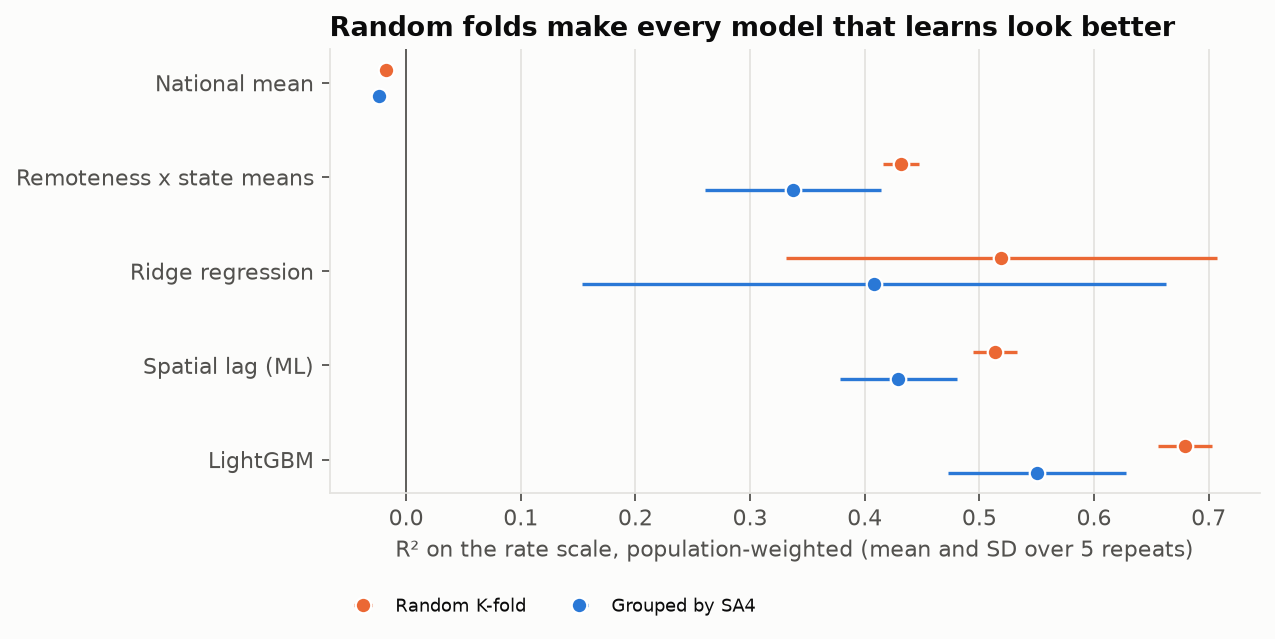

In [5]:
show("02_cv_comparison.png")

A few things jump out.

**Random folds flatter every model that learns from the data.** The gap between the two schemes is about 0.1 of
R² for each of them, and it's largest for LightGBM, the most flexible one. If I'd only reported random K-fold,
I'd have claimed LightGBM explains about two-thirds of the variation. With whole SA4s held out it's closer to
half. The national mean has no gap because it doesn't learn anything about place.

**The simple baseline is hard to beat by much.** Knowing just the state and how remote an area is gets about a
third of the way. All 42 features and boosted trees add roughly another 0.2 of R² on top of that.

**Ridge has a huge spread on the rate scale but does best on the log scale.** That looked like a bug, so I
checked which areas cause it.

In [6]:
misses = []
for cls in MODELS:
    m = r["models"][cls.name]
    for key in ("largest_over", "largest_under"):
        misses.append({"model": m["label"], "miss": key.replace("largest_", ""), **m[key]})
pd.DataFrame(misses).set_index(["model", "miss"])

sa3  observed  predicted
model                    miss                                                 
National mean            over          Southern Highlands    1548.0     2563.0
                         under              Alice Springs    9690.0     2481.0
Remoteness x state means over                   Esperance    1896.0     6574.0
                         under              Alice Springs    9690.0     2907.0
Ridge regression         over   Daly - Tiwi - West Arnhem    7109.0    28860.0
                         under                Maryborough    6620.0     3062.0
Spatial lag (ML)         over                   Fairfield    1907.0     4343.0
                         under                Maryborough    6620.0     3144.0
LightGBM                 over            South East Coast    1805.0     3078.0
                         under              Alice Springs    9690.0     3241.0

It's extrapolation. When the SA4 holding Daly - Tiwi - West Arnhem is left out, ridge sees feature values beyond
anything in its training data and carries the straight line on. On the log scale that's a moderate miss, but
after converting back to a rate it predicts several times the observed value. LightGBM has the opposite
problem: trees can't predict beyond the range they were trained on, so the most extreme remote areas (Alice
Springs, the Kimberley, Katherine) come out far too low.

So "which model is best" depends on the scale you score it on, and I think that's worth saying rather than
hiding. I picked LightGBM for the residual map because it scores best on the rate scale and its misses are
bounded, but I keep in mind that it can't predict the very highest rates.

## What about the spatial lag model?

The spatial lag model says an area's rate depends partly on its neighbours' rates. Fitted on all the areas at
once, it looks great. But to predict an area whose neighbours are also unknown (which is the honest situation
under SA4 folds), it can only use features, spread along the map. Feeding it the neighbours' real rates would
leak the answer, and one of the tests checks that it doesn't.

In [7]:
lag = r["interpretation"]["spatial_lag"]
pd.Series(
    {
        "rho (pull of the neighbours)": lag["rho"],
        "R2 (log), fitted on all areas, using neighbours' observed rates": lag[
            "r2_log_in_sample_with_neighbour_rates"
        ],
        "R2 (log), fitted on all areas, from features alone": lag["r2_log_in_sample_features_only"],
        "Moran's I of residuals, fitted on all areas": lag["residual_moran_I"],
        "R2 on log scale, SA4 folds": r["models"]["spatial_lag"]["spatial"]["r2_log"]["mean"],
        "Moran's I of residuals, SA4 folds": r["models"]["spatial_lag"]["residual_moran_I"],
    }
).to_frame("value")

,value
rho (pull of the neighbours),0.644
"R2 (log), fitted on all areas, using neighbours' observed rates",0.740
"R2 (log), fitted on all areas, from features alone",0.406
"Moran's I of residuals, fitted on all areas",0.044
"R2 on log scale, SA4 folds",0.365
"Moran's I of residuals, SA4 folds",0.602


This was one of the most useful things I learnt in the whole project. In-sample, the spatial lag model explains most of the
variation and leaves almost no spatial pattern in its residuals. Under SA4 folds it's one of the weaker models
on the log scale, and its residuals are nearly as clustered as the raw rates. To check where the drop comes from,
I also scored the in-sample fit using features alone, and it's already close to the cross-validated score. So
its strength came from knowing the neighbours' rates, which is exactly what you don't have for a new area. That's also why the random-fold scores
above are too optimistic: a random split quietly gives every model some of that neighbour information.

## What drives the predictions?

SHAP values split each LightGBM prediction into a contribution from each feature. The bar is the average size
of that contribution, and the colour is the direction (from the rank correlation between the feature and its
SHAP value). These come from LightGBM fitted on all areas, so they describe the model, not causes.

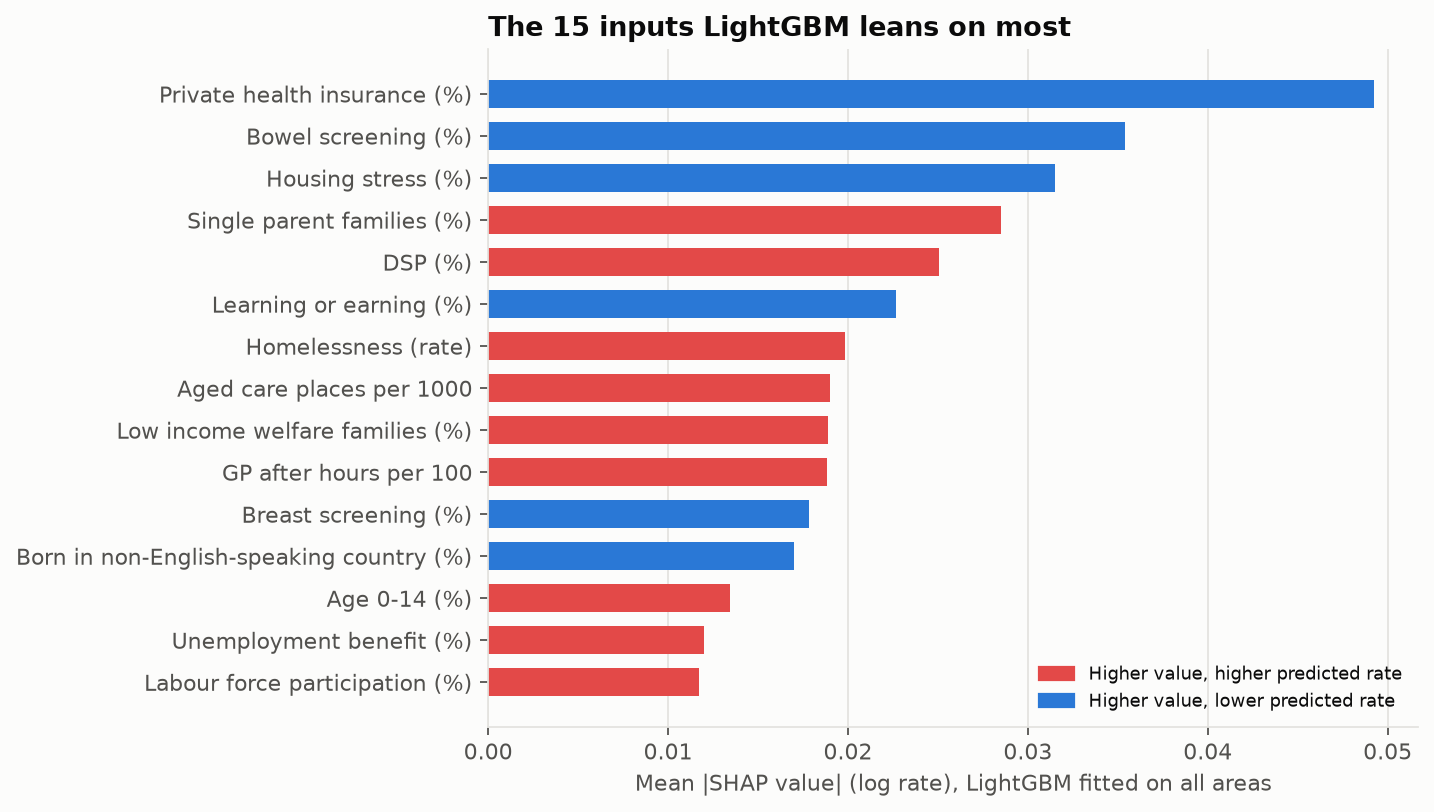

In [8]:
show("02_shap.png")

In [9]:
interp = r["interpretation"]
pd.DataFrame(
    {
        "ridge coefficient (standardised)": pd.Series(interp["ridge_standardised_coefficients"]),
    }
).sort_values("ridge coefficient (standardised)", key=abs, ascending=False)

,ridge coefficient (standardised)
private_health_insurance_pct,-0.102
bowel_screening_pct,-0.094
housing_stress_pct,-0.080
early_school_leavers_asr,-0.068
single_parent_families_pct,0.064
born_nes_pct,-0.055
homelessness_asr,0.041
jobless_families_pct,-0.031
age_65_plus_pct,-0.030
lf_participation_pct,0.028


Both models put private health insurance, bowel screening and housing stress near the top, and LightGBM adds
single-parent families, disability pensions and welfare dependence. Mostly that's "how well-off is this area, and
how much does it use preventive care".

Two directions need care:

- **Housing stress** pushes predictions *down*. I don't think housing stress protects anyone. Rents and
  mortgages are highest relative to income in the big cities, where rates are lowest, so it's acting as a
  marker for "city" once disadvantage is already counted.
- **Private health insurance** comes out on top. It's partly a wealth measure, but it could also reflect
  where people get treated. I ran the models without it as a check (below).

Overall GP attendances barely feature, which matches notebook 01. After-hours GP services do show up in
LightGBM, pointing towards *more* admissions. My guess is that lots of after-hours visits is a sign of unmet need
during the day rather than of good access, but I can't test that here.

## The residual map: better or worse than expected

This is the main result. For each area I compare the observed rate with what LightGBM expected, using the
out-of-fold predictions from the SA4-grouped CV (averaged over the 5 repeats). So every "expected" value comes
from a model that never saw that area or the rest of its SA4.

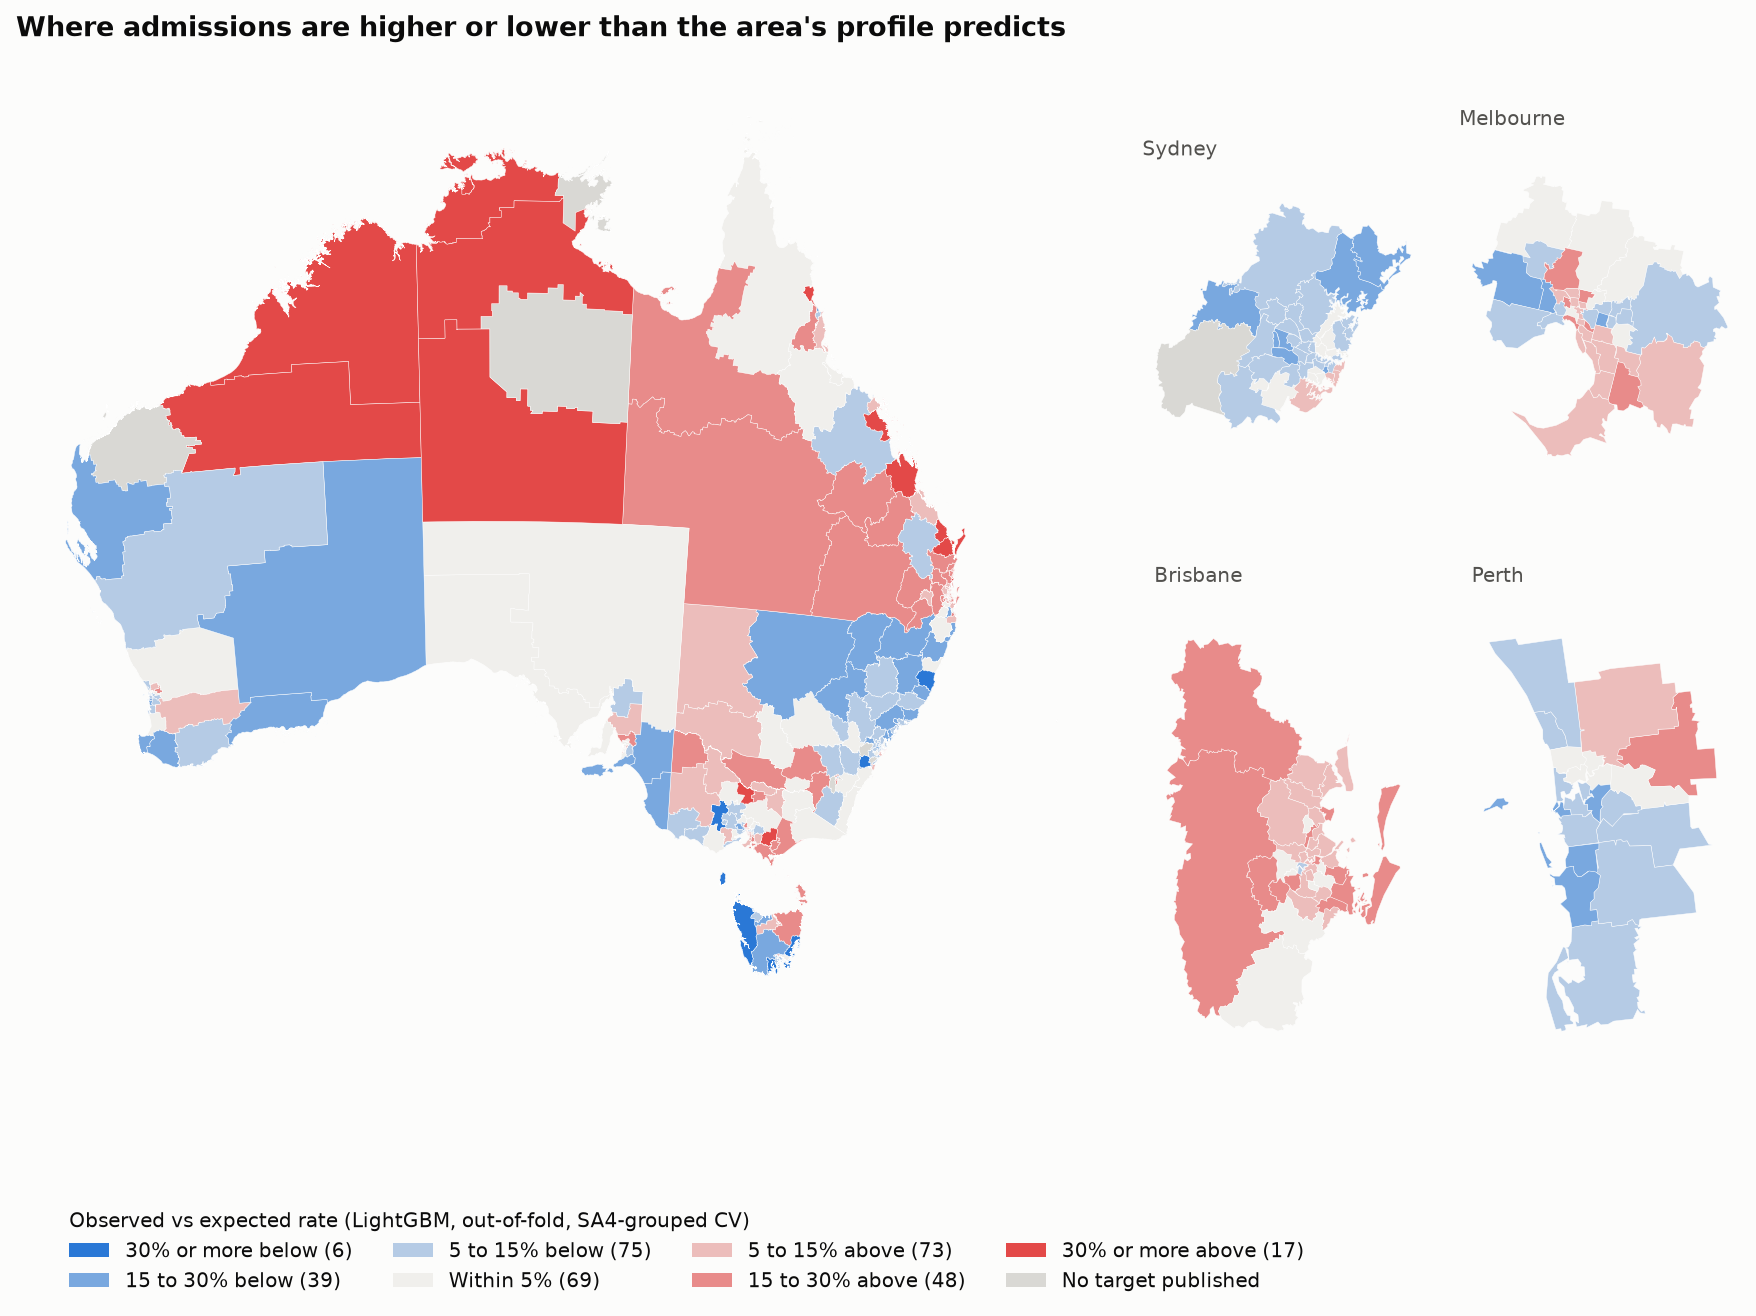

In [10]:
show("02_residual_map.png")

In [11]:
res = r["residuals"]
print(f"Model: {res['model']}")
within = res["share_of_population_within_10pct"]
print(f"Share of the population living in an SA3 within 10% of expected: {within:.0%}")
print(f"SA3s more than 20% above expected: {res['areas_over_20pct_above']}")
print(f"SA3s more than 20% below expected: {res['areas_over_20pct_below']}")
above = pd.DataFrame(res["most_above_expected"]).set_index("sa3")
below = pd.DataFrame(res["most_below_expected"]).set_index("sa3")
display(above, below)

Model: lightgbm
Share of the population living in an SA3 within 10% of expected: 50%
SA3s more than 20% above expected: 39
SA3s more than 20% below expected: 28


,state,observed,expected,pct_vs_expected
sa3,,,,
Maryborough,Queensland,6620.0,2997.0,120.90
Alice Springs,Northern Territory,9690.0,4623.0,109.60
Palmerston,Northern Territory,4773.0,2714.0,75.87
Hervey Bay,Queensland,4713.0,2746.0,71.62
Kimberley,Western Australia,8590.0,5131.0,67.40
Katherine,Northern Territory,7632.0,4646.0,64.26
Campaspe,Victoria,4214.0,2785.0,51.28
East Pilbara,Western Australia,5473.0,3625.0,50.97
Daly - Tiwi - West Arnhem,Northern Territory,7109.0,4750.0,49.65


,state,observed,expected,pct_vs_expected
sa3,,,,
West Coast,Tasmania,2140.0,3359.0,-36.29
South East Coast,Tasmania,1805.0,2825.0,-36.12
Maryborough - Pyrenees,Victoria,2335.0,3577.0,-34.72
Huon - Bruny Island,Tasmania,1810.0,2706.0,-33.11
Southern Highlands,New South Wales,1548.0,2295.0,-32.55
Kempsey - Nambucca,New South Wales,2546.0,3660.0,-30.44
Esperance,Western Australia,1896.0,2701.0,-29.81
Central Highlands (Tas.),Tasmania,2391.0,3361.0,-28.86
Moree - Narrabri,New South Wales,2752.0,3804.0,-27.65


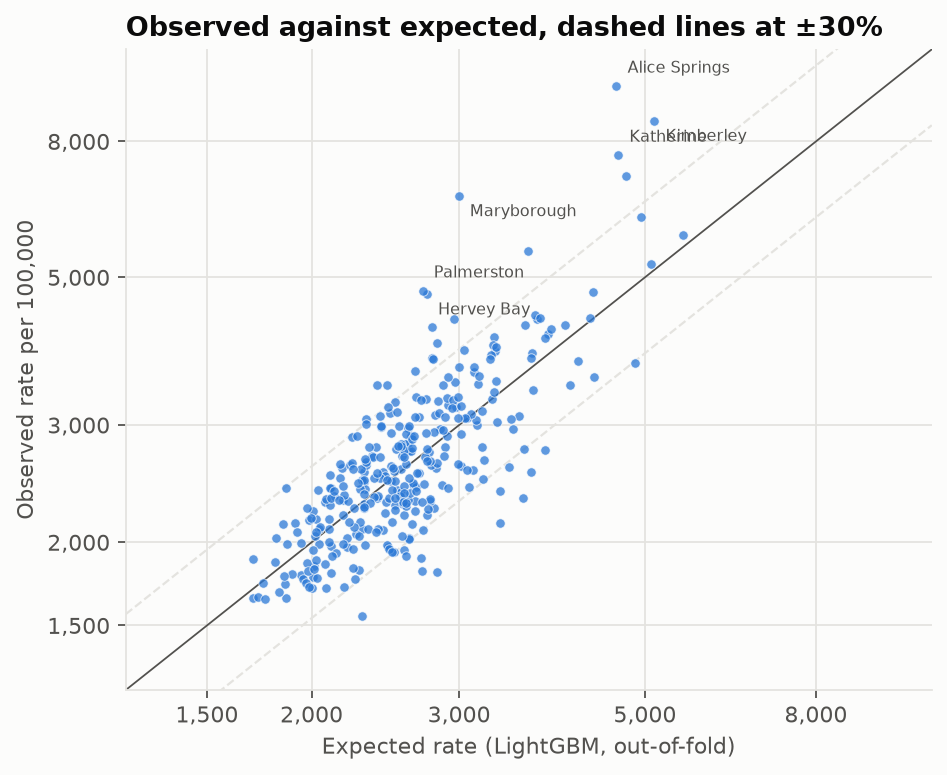

In [12]:
show("02_observed_vs_expected.png")

The areas well **above** expected are mostly in the NT, the Kimberley and the Pilbara, and these are partly the
tree problem from earlier: LightGBM can't reach their real rates. The ones I find more interesting are the
non-remote areas. Maryborough in Queensland is the biggest gap in the whole country, at about double what its
profile predicts, and neighbouring Hervey Bay is also near the top. Notebook 01 already flagged Maryborough as
an outlier, and the raw AIHW tables show it has been well above its neighbours in every year since 2017-18, so
this isn't a one-year blip.

The areas well **below** expected are a mix of Tasmanian areas, regional New South Wales, Victoria and Western
Australia, and Fairfield in Sydney, the very disadvantaged but low-rate area I noted in notebook 01. So it does stand out once
its profile is taken into account.

The residuals also lean by state, even though no model was given the state:

In [13]:
pd.Series(res["pct_vs_expected_by_state"], name="% vs expected (population-weighted)").sort_values(
    ascending=False
).to_frame()

,% vs expected (population-weighted)
Northern Territory,57.160
Queensland,12.230
Australian Capital Territory,10.610
Victoria,2.288
South Australia,0.794
Western Australia,-6.864
New South Wales,-7.708
Tasmania,-8.502


Queensland and the ACT come out above expected, while New South Wales, Tasmania and Western Australia come out
below. The NT figure is mostly the extrapolation problem again. I can't tell from this data whether the state
lean is about health systems (for example, how much care happens outside hospital) or about how each state's
hospitals record and admit patients. Either way, it suggests a state-level factor the features don't capture.

Finally, are the leftover errors still clustered?

Moran's I of the log residual: 0.51
High-high           32
Low-high             2
Low-low             49
High-low             6
Not significant    238
Name: SA3s, dtype: int64


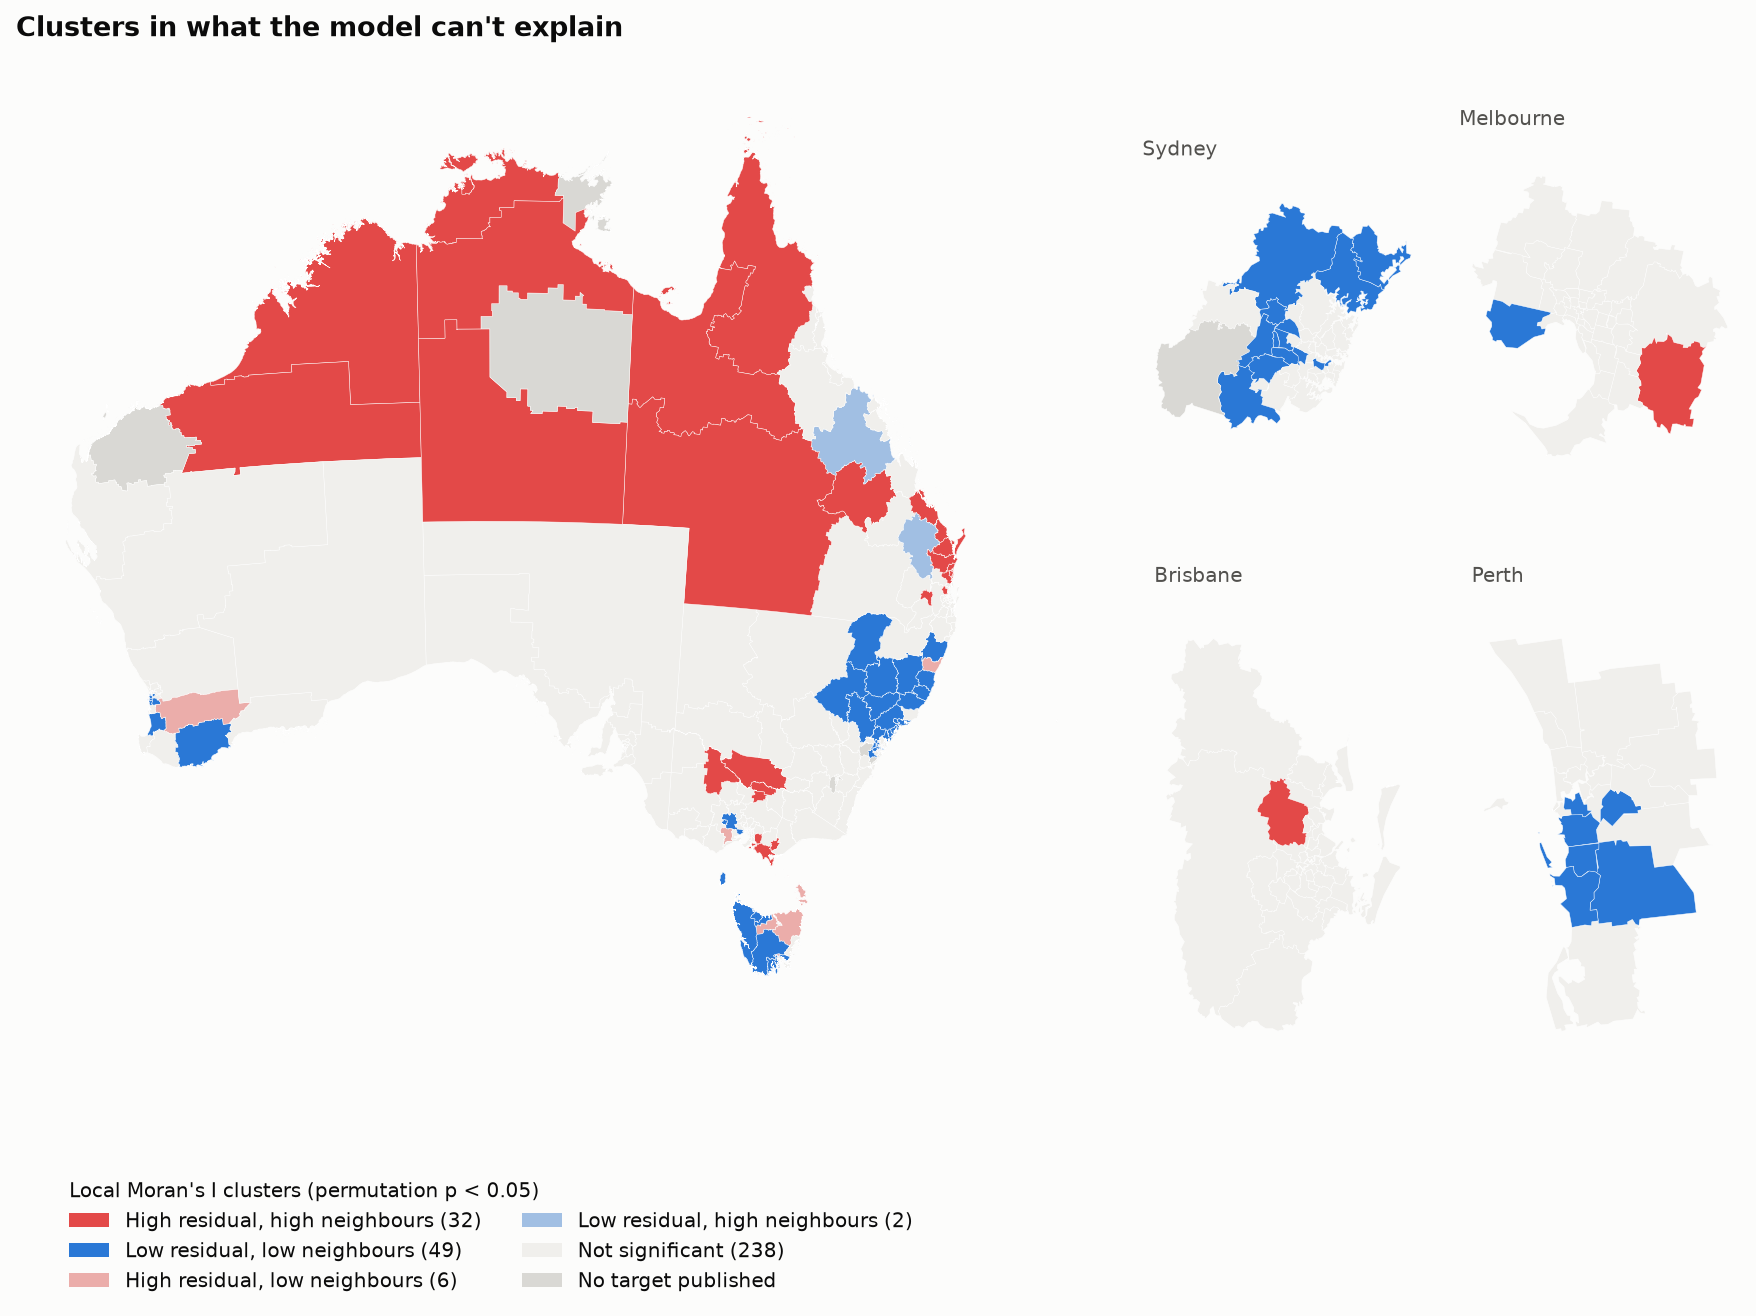

In [14]:
print(f"Moran's I of the log residual: {res['moran_log_ratio']['I']:.2f}")
print(pd.Series(res["lisa_clusters"], name="SA3s"))
show("02_residual_lisa_map.png")

Yes. The model takes out a fair bit of the clustering (Moran's I falls from about 0.7 to about 0.5), but a lot is
left, which means neighbouring areas share something the features don't describe. Combined with the state lean,
that's the strongest hint for what to add next.

## Sensitivity checks

The same ridge and LightGBM models under SA4 folds, with other feature sets and targets. R² is on the rate
scale.

In [15]:
sens = r["sensitivity"]
pd.DataFrame(
    {
        name: {
            "SA3s": v["areas"],
            "ridge R2": v["ridge"]["r2"]["mean"],
            "ridge R2 (log)": v["ridge"]["r2_log"]["mean"],
            "LightGBM R2": v["lightgbm"]["r2"]["mean"],
            "LightGBM R2 (log)": v["lightgbm"]["r2_log"]["mean"],
        }
        for name, v in sens.items()
    }
).T

,SA3s,ridge R2,ridge R2 (log),LightGBM R2,LightGBM R2 (log)
main,327.0,0.408,0.613,0.550,0.581
without_private_insurance,327.0,0.224,0.569,0.528,0.556
with_tier_b_health_status,327.0,-5.425,0.614,0.626,0.664
chronic_conditions_target,326.0,0.328,0.638,0.548,0.610
acute_conditions_target,326.0,0.497,0.575,0.538,0.553
target_2018_19_without_act,315.0,0.388,0.694,0.645,0.655


- **Without private insurance**, LightGBM barely changes. The other wealth features cover for it. Ridge drops
  more, mostly through the same extrapolation problem.
- **Adding the Tier B health-status features** (diabetes, smoking, self-rated health and so on) helps LightGBM.
  That's expected, because they sit on the path to admission, which is why they're only a sensitivity check and
  not in the main model. Ridge's rate-scale R² falls apart here: more features give it more ways to extrapolate.
  Its log-scale R² is fine.
- **Chronic and acute conditions separately** behave much like the total.
- **2018-19 (before COVID, ACT left out)** is predicted at least as well as 2023-24, so the features explain the
  pre-COVID rates just as well. That doesn't prove the residual map would look the same for 2018-19, which I
  haven't checked.

## Limitations

- **Ecological fallacy.** Everything is at area level. "Areas with more single-parent families have higher
  rates" says nothing about whether single parents are admitted more.
- **The tree ceiling.** LightGBM can't predict above the highest rates it was trained on, so the most remote
  areas look "worse than expected" partly for that reason.
- **Suppressed areas.** Barkly, East Arnhem and West Pilbara have no published rate, and they are probably
  among the highest. The model never sees them.
- **Boundaries and years.** Features come from 2021 to 2025 and from different boundary editions, joined to
  2021 SA3s.
- **No tuning.** LightGBM uses fixed settings. Tuning inside each fold might add a little, but I wanted the CV
  comparison to stay clean.

## What's next

`uv run dap health report` turns the residual map into an interactive map you can zoom into. After that I'd
like to look closer at Maryborough and at the state lean. A state term or a regional random effect would be
the obvious next model.